# Logistic Regression

Despite its name, **Logistic Regression** is a classification algorithm, not a regression one. It models the probability that a given input belongs to a particular class, and produces binary predictions (0 or 1) by applying a threshold to those probabilities.

It is one of the most interpretable and widely deployed classifiers in industry, serving as a standard baseline for binary classification tasks in healthcare, finance, marketing, and many other domains.

The `ifri-mini-ml-lib` implementation uses **gradient descent with momentum** for optimization, includes automatic **polynomial feature expansion** for non-linear decision boundaries, and supports **early stopping** to prevent unnecessary computation.

## 1. Key Concepts

### From Linear to Probabilistic

Linear regression predicts a continuous value $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$. For classification, we need this output to be a valid probability — a number between 0 and 1. The **sigmoid function** (also called logistic function) achieves exactly this:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The model computes:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$
 

 <img src="../assets/imgs/regression_logistic/sigmoid_curve.png" alt="Sigmoid Function" style="display:block; margin: 0 auto; width: 50%; height: auto;"/>

*Figure 1: The sigmoid function maps any real number to the interval (0, 1), making it suitable for probability estimation.*  

*Source: Mukesh Chaudhary, Medium — https://medium.com/@cmukesh8688/logistic-regression-sigmoid-function-and-threshold-b37b82a4cd79*

### Decision Boundary

A threshold (default: 0.5) is applied to convert probabilities into class labels:

$$\hat{y} = \begin{cases} 1 & \text{if } P(y=1 \mid \mathbf{x}) \geq 0.5 \\ 0 & \text{otherwise} \end{cases}$$

The decision boundary is the set of points where $P(y=1 \mid \mathbf{x}) = 0.5$, i.e., where $\mathbf{w}^\top \mathbf{x} + b = 0$.

### Numerical Stability

In practice, computing $e^{-z}$ for very large or very small values of $z$ can cause overflow. The implementation clips $z$ to $[-709, 709]$ (the float64 precision boundary) before applying the exponential:

```python
z_clipped = np.clip(z, -709, 709)
return 1 / (1 + np.exp(-z_clipped))
```

### Polynomial Feature Expansion

When the decision boundary is not linear in the original feature space, the `fit` method automatically adds **squared terms** for each feature (when $n_{\text{features}} \leq 10$):

$$\mathbf{x} = [x_1, x_2, \ldots, x_n] \rightarrow [x_1, x_2, \ldots, x_n, x_1^2, x_2^2, \ldots, x_n^2]$$

This allows the model to learn curved, non-linear decision boundaries while keeping the training process linear in the expanded feature space.

## 2. Loss Function and Optimization

### Binary Cross-Entropy Loss

Logistic regression is trained by minimizing the **Binary Cross-Entropy** (also called log-loss), which measures how well the predicted probabilities match the true binary labels:

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Where $\hat{p}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$ is the predicted probability for sample $i$.

A small constant $\epsilon = 10^{-15}$ is added to prevent $\log(0)$ from causing numerical issues:

```python
y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
```

### Gradient Descent with Momentum

The gradients of the loss with respect to the parameters are:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{m} X^\top (\hat{\mathbf{p}} - \mathbf{y}), \quad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{p}_i - y_i)$$

Standard gradient descent updates parameters as $\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}}\mathcal{L}$. The `ifri-mini-ml-lib` implementation adds **momentum** to accelerate convergence and reduce oscillations:

$$v_w^{(t)} = \beta \cdot v_w^{(t-1)} - \alpha \cdot \nabla_{\mathbf{w}}\mathcal{L}$$
$$\mathbf{w}^{(t)} \leftarrow \mathbf{w}^{(t-1)} + v_w^{(t)}$$

Where $\beta$ is the momentum coefficient (default: `0.9`).

Unlike standard gradient descent used in Linear Regression which follows only the 
current gradient, momentum accumulates past gradients to build up speed in consistent 
directions and dampen oscillations. This leads to faster and more stable convergence, 
especially when the loss surface has narrow valleys or saddle points. The closer $\beta$ 
is to 1, the more the algorithm "remembers" past gradients — with `0.9` meaning 90% 
of the previous update direction is retained at each step.



> **Intuition**: Momentum acts like a ball rolling downhill — it accumulates speed in the direction of consistent gradients and dampens oscillations in directions where gradients frequently change sign.

### Early Stopping

The loss is tracked every 10 iterations. If the change in loss between two consecutive checkpoints is smaller than `tol` (default: `1e-4`), training stops early:

```python
if abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
    break
```

This avoids wasting computation once the model has converged.

## 3. Pseudo-algorithm

```
Input: X         ← matrix of shape [n_samples, n_features]
       y         ← binary labels in {0, 1}, shape [n_samples]
       α         ← learning rate
       β         ← momentum coefficient
       max_iter  ← maximum number of iterations
       tol       ← early stopping tolerance

# Feature expansion
if n_features ≤ 10:
    X ← column_stack(X, X²)          # Add squared terms

# Initialization
w ← zeros(n_features_expanded)
b ← 0
v_w ← 0, v_b ← 0                     # Momentum accumulators
loss_history ← []

for t = 1 to max_iter do
    # Forward pass
    z  ← X · w + b
    p̂  ← sigmoid(z)                  # Predicted probabilities

    # Backward pass
    dw ← (1/m) · Xᵀ · (p̂ - y)
    db ← (1/m) · sum(p̂ - y)

    # Momentum update
    v_w ← β · v_w - α · dw
    v_b ← β · v_b - α · db
    w   ← w + v_w
    b   ← b + v_b

    # Early stopping (every 10 iterations)
    if t mod 10 == 0:
        loss ← cross_entropy(y, p̂)
        loss_history.append(loss)
        if |loss_history[-1] - loss_history[-2]| < tol:
            break
end for

Return w, b

# Prediction
function predict(X, threshold=0.5):
    X ← expand_polynomial_features(X)
    p̂  ← sigmoid(X · w + b)
    return (p̂ ≥ threshold).astype(int)
```

## 4. Implementation

For this implementation, we use the **Breast Cancer Wisconsin** dataset, a standard binary classification benchmark. The task is to predict whether a tumor is malignant (1) or benign (0) from 30 numerical features computed from digitized images of fine needle aspirate biopsies.

It contains 569 samples and is well-suited to demonstrate logistic regression because the classes are approximately balanced and the features are continuous.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from ifri_mini_ml_lib.preprocessing.preparation import DataSplitter
from ifri_mini_ml_lib.preprocessing.preparation import DataSplitter, StandardScaler


cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')  # 1 = malignant, 0 = benign


In [2]:
splitter = DataSplitter(seed=42)
X_train, X_test, y_train, y_test = splitter.train_test_split(X, y, test_size=0.2)

# Convertir en numpy après le split
X_train, X_test = X_train.values, X_test.values
y_train, y_test = y_train.values, y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### With Scikit-learn

In [3]:
import time
from sklearn.linear_model import LogisticRegression as SklearnLR

start_1 = time.perf_counter()
sk_model = SklearnLR(max_iter=1000, random_state=42)
sk_model.fit(X_train_scaled, y_train)
end_1 = time.perf_counter()

y_pred_sk = sk_model.predict(X_test_scaled)

### With ifri-mini-ml-lib

In [4]:
from ifri_mini_ml_lib.classification import LogisticRegression

start_2 = time.perf_counter()
lr = LogisticRegression(learning_rate=0.01, max_iter=1000, tol=1e-4, momentum=0.9)
lr.fit(X_train_scaled, y_train)
end_2 = time.perf_counter()

y_pred_lr = lr.predict(X_test_scaled)

In [5]:
from ifri_mini_ml_lib.metrics.classification import accuracy, f1_score, recall, precision

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Recall', 'Precision', 'Time (s)'],
    'Scikit-learn': [
        accuracy(y_test, y_pred_sk),
        f1_score(y_test, y_pred_sk),
        recall(y_test, y_pred_sk),
        precision(y_test, y_pred_sk),
        round(end_1 - start_1, 6)
    ],
    'ifri-mini-ml-lib': [
        accuracy(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        recall(y_test, y_pred_lr),
        precision(y_test, y_pred_lr),
        round(end_2 - start_2, 6)
    ],
})

results.set_index('Metric')

,Scikit-learn,ifri-mini-ml-lib
Metric,,
Accuracy,0.973451,0.982301
F1 Score,0.979021,0.985915
Recall,0.985915,0.985915
Precision,0.972222,0.985915
Time (s),0.041407,0.067939


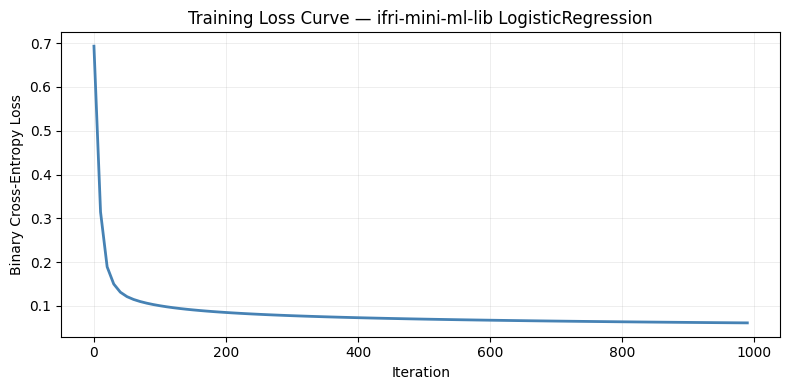

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot([i * 10 for i in range(len(lr.loss_history))], lr.loss_history,
         color='steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve — ifri-mini-ml-lib LogisticRegression')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Interactive Demo

In [7]:
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import matplotlib.pyplot as plt
import numpy as np

feature_names = list(cancer.feature_names)

def plot_logistic_decision(feature_x=feature_names[0], feature_y=feature_names[1],
                            learning_rate=0.01, max_iter=500, momentum=0.9):
    """
    Interactive 2D decision boundary visualization.
    Trains logistic regression on two chosen features and plots
    the predicted class regions alongside test points.
    """
    idx_x = feature_names.index(feature_x)
    idx_y = feature_names.index(feature_y)

    X_2d_train = X_train_scaled[:, [idx_x, idx_y]]
    X_2d_test  = X_test_scaled[:, [idx_x, idx_y]]

    model = LogisticRegression(learning_rate=learning_rate, max_iter=max_iter, momentum=momentum)
    model.fit(X_2d_train, y_train)

    # Build grid
    x_min, x_max = X_2d_test[:, 0].min() - 0.5, X_2d_test[:, 0].max() + 0.5
    y_min, y_max = X_2d_test[:, 1].min() - 0.5, X_2d_test[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    acc = accuracy(y_test, model.predict(X_2d_test))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    scatter = ax.scatter(X_2d_test[:, 0], X_2d_test[:, 1], c=y_test,
                         cmap='coolwarm', edgecolors='k', s=40, linewidths=0.5)
    plt.colorbar(scatter, ax=ax, label='Class (0=Benign, 1=Malignant)')
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f'Decision Boundary — Accuracy: {acc:.3f}')
    plt.tight_layout()
    plt.show()

interact(
    plot_logistic_decision,
    feature_x=Dropdown(options=feature_names, value=feature_names[0], description='Feature X:'),
    feature_y=Dropdown(options=feature_names, value=feature_names[1], description='Feature Y:'),
    learning_rate=FloatSlider(min=0.001, max=0.1, step=0.005, value=0.01, description='LR:'),
    max_iter=IntSlider(min=100, max=2000, step=100, value=500, description='Max Iter:'),
    momentum=FloatSlider(min=0.0, max=0.99, step=0.05, value=0.9, description='Momentum:')
);

interactive(children=(Dropdown(description='Feature X:', options=(np.str_('mean radius'), np.str_('mean textur…

The interactive demo above visualizes the decision boundary learned by the logistic regression model in a 2D feature subspace. You can:
- Choose any two features from the dataset as axes
- Adjust the learning rate, number of iterations, and momentum coefficient
- Observe how the shape of the decision boundary changes, and how accuracy responds to hyperparameter choices

Note that projecting to two features naturally loses information — the full model trained on all features will achieve higher accuracy.

## 6. Real-life Applications

Logistic regression is one of the most deployed machine learning models in production systems, valued for its interpretability and probabilistic outputs.

**Medical Diagnosis**: Logistic regression is widely used to predict the probability of disease given patient features — for example, diagnosing breast cancer from biopsy features (as in this notebook), predicting diabetes risk from glucose levels and BMI, or screening for cardiovascular disease. Its probability outputs allow clinicians to calibrate risk thresholds according to the clinical context.

**Credit Scoring and Loan Approval**: Banks and microfinance institutions use logistic regression to assess whether a borrower is likely to default. Each coefficient directly quantifies how much a given financial indicator (income, debt ratio, payment history) increases or decreases the default risk — a property that regulators often require for auditability.

**Email Spam Detection**: One of the earliest large-scale applications of logistic regression was email filtering. Features such as word frequencies and sender reputation are used to estimate the probability that a message is spam, enabling thresholded filtering.

**Marketing and Churn Prediction**: Companies predict whether a customer is likely to cancel a subscription or respond to a campaign, allowing targeted intervention. The model's probability scores enable prioritization: instead of acting on all customers equally, teams can focus on those with the highest predicted churn probability.

**Natural Language Processing (NLP)**: As a linear classifier in a high-dimensional bag-of-words feature space, logistic regression is a strong and fast baseline for text classification tasks such as sentiment analysis, topic labeling, and intent detection.

## 7. Limitations and Challenges

**Binary Classification Only**: The current `LogisticRegression` implementation is designed exclusively for binary classification (two classes). Multi-class problems (e.g., classifying among three or more categories) require extensions such as One-vs-Rest (OvR) or Softmax Regression, which are not yet included in `ifri-mini-ml-lib`.

**Linear Decision Boundary by Default**: Standard logistic regression learns a linear boundary in the original feature space. While the automatic polynomial expansion (squared terms) extends this capability, it only adds degree-2 terms and does not cover all non-linear configurations. For highly complex boundaries, tree-based models or neural networks may be more appropriate.

**Feature Scaling Required**: Gradient descent-based optimization is sensitive to feature scale. Without standardization, features with large magnitudes will dominate the gradient updates and slow or destabilize convergence. Always apply `StandardScaler` (or `MinMaxScaler`) before training, as shown in the implementation section.

**Sensitivity to Class Imbalance**: When one class is much more frequent than the other, the model tends to be biased toward predicting the majority class. The current implementation does not handle class weights or resampling. Using the `recall` and `f1_score` metrics (rather than accuracy alone) from `ifri-mini-ml-lib` helps detect this issue.

**Hyperparameter Sensitivity**: The model's behavior depends on `learning_rate`, `momentum`, `max_iter`, and `tol`. Poor choices can lead to slow convergence, oscillation, or premature stopping. Using the `GridSearch` or `BayesianSearch` modules from the optimization module is recommended for systematic tuning.

## 8. References

1. *Logistic Regression*, Scikit-learn Documentation — https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

2. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Chapter 4: Linear Models for Classification.

3. Ng, A. — *CS229 Lecture Notes: Supervised Learning, Discriminative Algorithms* — https://cs229.stanford.edu/notes2022fall/main_notes.pdf

4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 6: Deep Feedforward Networks. — https://www.deeplearningbook.org/

5. *Breast Cancer Wisconsin Dataset* — Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1994). Machine learning techniques to diagnose breast cancer from fine-needle aspirates. *Cancer Letters*, 77(2-3), 163-171.